# CWT Consensus Peak Detection

This notebook illustrates how Osprey detects chromatographic peaks in fragment ion
chromatograms (XICs) using the **Continuous Wavelet Transform (CWT) with a Mexican Hat
wavelet**.

## Key concepts

- **Mexican Hat wavelet**: a matched filter for Gaussian-like peaks — positive response at
  peak centres, negative response in flanking regions.
- **Consensus across transitions**: the *median* CWT coefficient across all fragment XICs
  at each scan is used for peak detection. A peak must be supported by the majority of
  transitions to survive — single-fragment interference is automatically suppressed.
- **Boundary detection**: zero-crossings of the consensus signal define initial boundaries;
  these are extended to ±2σ for ~95 % Gaussian area capture, subject to a valley guard
  that stops the extension when a neighbouring peak is entered.

The notebook works entirely on **synthetic data** so it can be run without any mzML files.
Real data can be substituted in section 3.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import convolve
from scipy.ndimage import uniform_filter1d

rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. The Mexican Hat Wavelet at Different Scales

The **Mexican Hat (Ricker) wavelet** is the negative normalised second derivative of a Gaussian:

$$\psi(t) = \frac{2}{\sqrt{3\sigma}\,\pi^{1/4}}\left(1 - \frac{t^2}{\sigma^2}\right) e^{-t^2/(2\sigma^2)}$$

The scale parameter σ controls which peak widths the wavelet is tuned to detect.
Osprey estimates σ from the median FWHM of the observed fragment XICs.

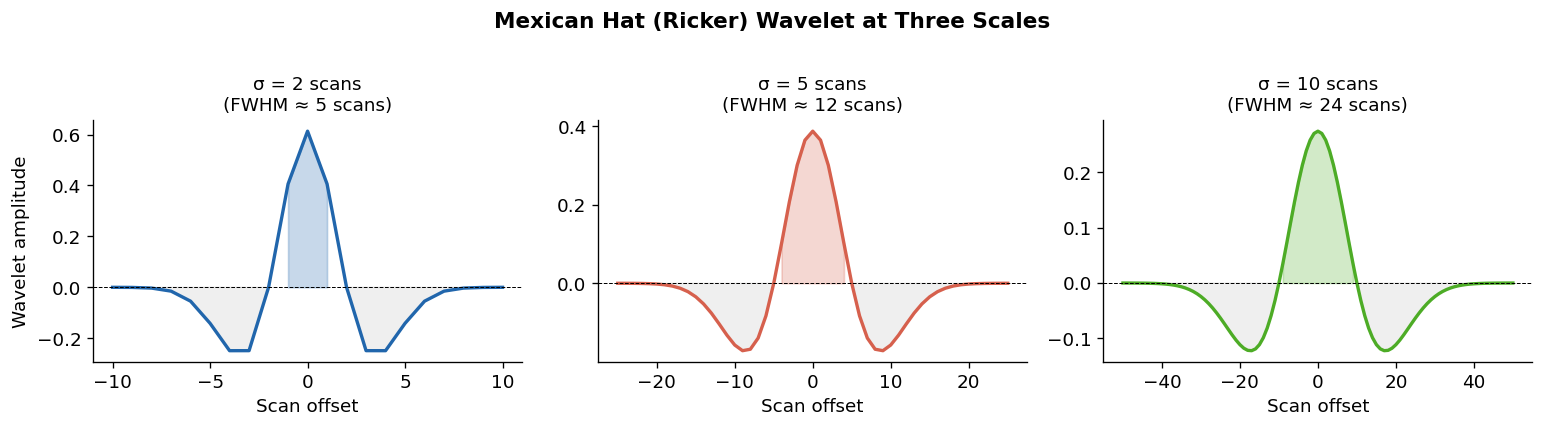

The positive centre (blue) responds to peaks; the negative troughs penalise flat flanks.


In [12]:
def mexican_hat(t, sigma):
    """Mexican Hat (Ricker) wavelet, normalised to unit L2 norm."""
    norm = 2.0 / (np.sqrt(3 * sigma) * np.pi ** 0.25)
    return norm * (1 - (t / sigma) ** 2) * np.exp(-t ** 2 / (2 * sigma ** 2))

def make_kernel(sigma, radius=None):
    """Discretised Mexican Hat kernel (zero-mean corrected)."""
    if radius is None:
        radius = int(np.ceil(5 * sigma))
    t = np.arange(-radius, radius + 1, dtype=float)
    k = mexican_hat(t, sigma)
    k -= k.mean()   # DC correction
    return t, k

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=False)
sigmas = [2, 5, 10]
colors = ['#2166ac', '#d6604d', '#4dac26']

for ax, sigma, color in zip(axes, sigmas, colors):
    t, k = make_kernel(sigma)
    ax.plot(t, k, color=color, lw=2)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.fill_between(t, k, 0, where=(k > 0), alpha=0.25, color=color)
    ax.fill_between(t, k, 0, where=(k < 0), alpha=0.12, color='gray')
    ax.set_title(f'σ = {sigma} scans\n(FWHM ≈ {2.355*sigma:.0f} scans)', fontsize=11)
    ax.set_xlabel('Scan offset')

axes[0].set_ylabel('Wavelet amplitude')
fig.suptitle('Mexican Hat (Ricker) Wavelet at Three Scales', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('The positive centre (blue) responds to peaks; the negative troughs penalise flat flanks.')

## 2. Simulate Fragment XICs

We simulate a **6-fragment precursor** with:
- A real peptide peak at RT = 12 min  
- One fragment suffering **co-elution interference** (a foreign peptide) at RT = 9 min  
- Gaussian noise added throughout  

This mirrors the DIA challenge: several fragments track the same peptide (target peak),
but individual fragments can be contaminated by co-isolated interfering peptides.

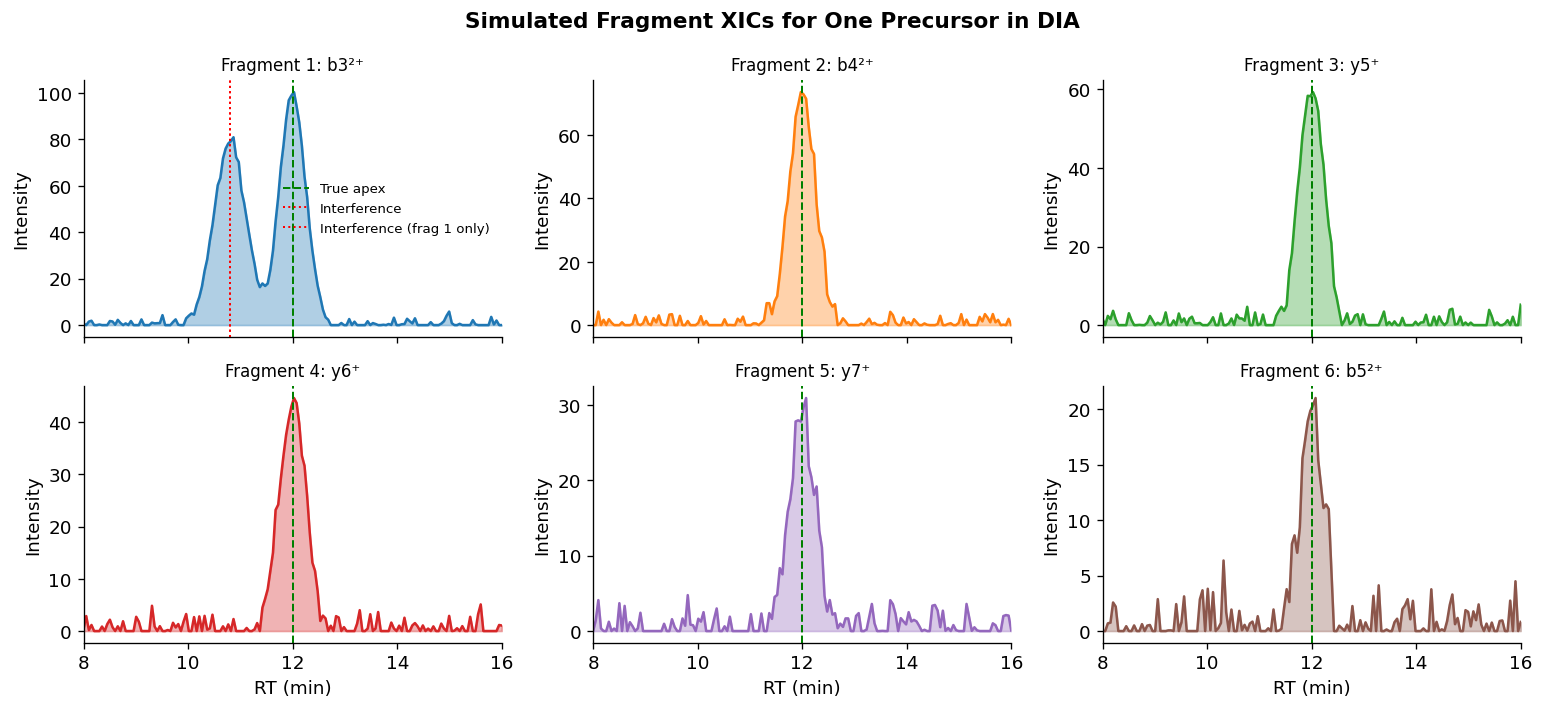

In [13]:
def gaussian_peak(rt, apex, height, sigma):
    return height * np.exp(-0.5 * ((rt - apex) / sigma) ** 2)

# Retention time axis (minutes)
rt = np.linspace(8, 16, 160)

# Shared peptide peak at RT = 12 min  
peptide_peak_sigma = 0.25  # ~35 s wide
peptide_apex_rt = 12.0

# Fragment relative intensities (from library)
library_intensities = np.array([100, 75, 60, 45, 30, 20], dtype=float)
frag_labels = ['b3²⁺', 'b4²⁺', 'y5⁺', 'y6⁺', 'y7⁺', 'b5²⁺']
frag_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Interference: only hits fragment 0 at RT = 9 min
interference_rt   = 10.8
interference_ints = np.array([80, 0, 0, 0, 0, 0], dtype=float)

xics = []
for i in range(6):
    signal = (gaussian_peak(rt, peptide_apex_rt, library_intensities[i], peptide_peak_sigma)
              + gaussian_peak(rt, interference_rt, interference_ints[i], 0.30)
              + rng.normal(0, 2.0, len(rt)))
    signal = np.clip(signal, 0, None)
    xics.append(signal)

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
axes = axes.ravel()

for i, (ax, color, label) in enumerate(zip(axes, frag_colors, frag_labels)):
    ax.fill_between(rt, xics[i], alpha=0.35, color=color)
    ax.plot(rt, xics[i], color=color, lw=1.5)
    ax.axvline(peptide_apex_rt, color='green', lw=1.2, ls='--', label='True apex')
    if i == 0:
        ax.axvline(interference_rt, color='red', lw=1.2, ls=':', label='Interference')
    ax.set_title(f'Fragment {i+1}: {label}', fontsize=10)
    ax.set_xlim(rt[0], rt[-1])
    ax.set_ylabel('Intensity')
    if i >= 3:
        ax.set_xlabel('RT (min)')

# Legend on first panel
axes[0].axvline(interference_rt, color='red', lw=1.2, ls=':', label='Interference (frag 1 only)')
axes[0].legend(fontsize=8, frameon=False)

fig.suptitle('Simulated Fragment XICs for One Precursor in DIA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Apply the Mexican Hat Wavelet to Each Fragment XIC

Each fragment XIC is convolved independently with the Mexican Hat kernel.
The CWT response is positive where the signal looks like a peak of the right width,
and negative in flat or trough regions.

Estimated CWT scale: σ = 5.0 scans  (FWHM ≈ 0.59 min)


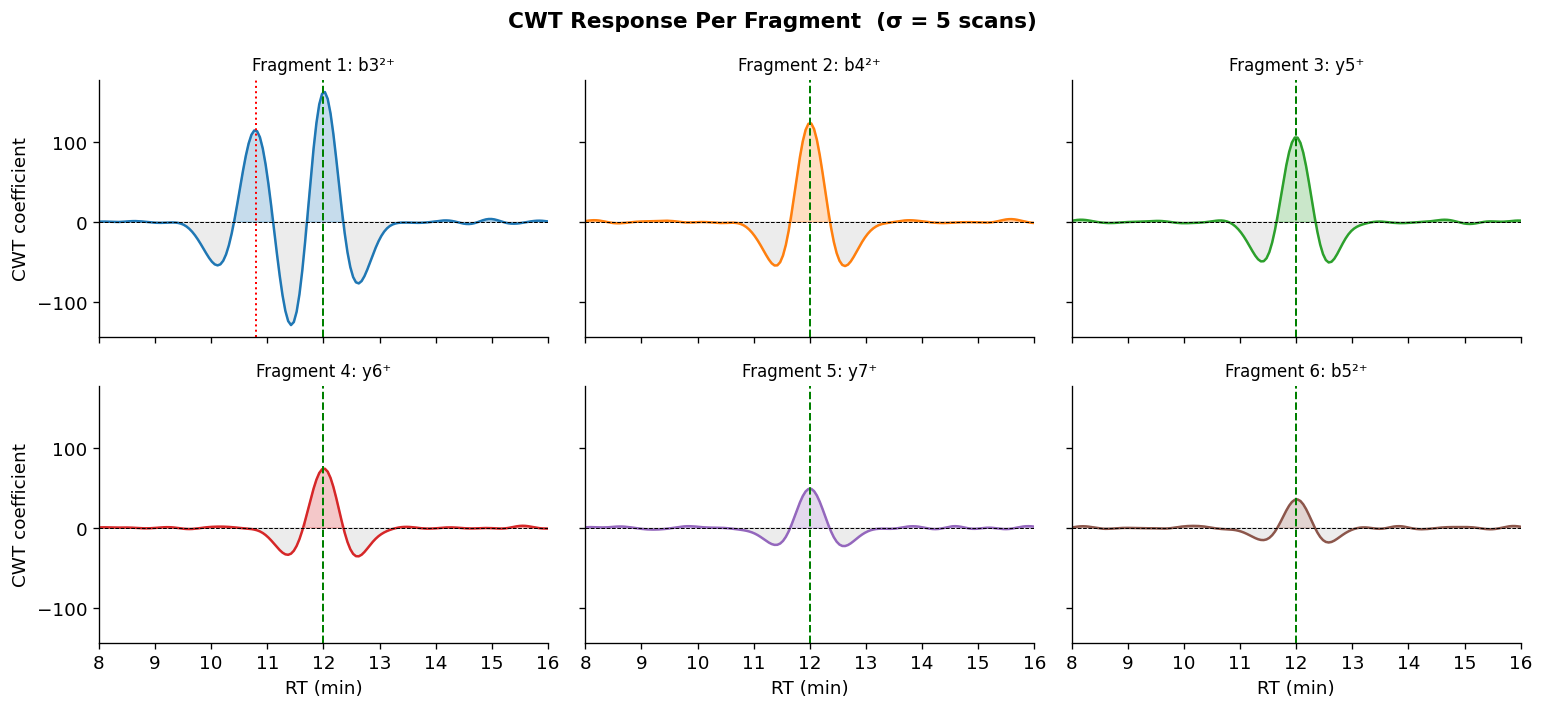

Fragment 1 shows a spurious positive response at RT ≈ 9.8 min (interference).
Fragments 2–6 only respond at the true peptide apex.


In [14]:
def cwt_convolve(signal, sigma):
    """Convolve signal with Mexican Hat kernel, 'same' size, zero-padded."""
    _, kernel = make_kernel(sigma)
    return convolve(signal, kernel, mode='same')

# Estimate sigma from data: median FWHM / 2.355
# For our synthetic data we know sigma ~ 0.25 min; convert to scan units
scan_width_min = rt[1] - rt[0]          # minutes per scan ≈ 0.05  
true_sigma_scans = peptide_peak_sigma / scan_width_min   # ≈ 5 scans
sigma_est = max(2.0, min(20.0, true_sigma_scans))
print(f'Estimated CWT scale: σ = {sigma_est:.1f} scans  '
      f'(FWHM ≈ {2.355*sigma_est*scan_width_min:.2f} min)')

cwt_coeffs = [cwt_convolve(xic, sigma_est) for xic in xics]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
axes = axes.ravel()

for i, (ax, color, label) in enumerate(zip(axes, frag_colors, frag_labels)):
    ax.plot(rt, cwt_coeffs[i], color=color, lw=1.5)
    ax.fill_between(rt, cwt_coeffs[i], 0, where=(np.array(cwt_coeffs[i]) > 0),
                    alpha=0.25, color=color)
    ax.fill_between(rt, cwt_coeffs[i], 0, where=(np.array(cwt_coeffs[i]) < 0),
                    alpha=0.15, color='gray')
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.axvline(peptide_apex_rt, color='green', lw=1.2, ls='--')
    if i == 0:
        ax.axvline(interference_rt, color='red', lw=1.2, ls=':')
    ax.set_title(f'Fragment {i+1}: {label}', fontsize=10)
    ax.set_xlim(rt[0], rt[-1])
    if i >= 3:
        ax.set_xlabel('RT (min)')

axes[0].set_ylabel('CWT coefficient')
axes[3].set_ylabel('CWT coefficient')
fig.suptitle(f'CWT Response Per Fragment  (σ = {sigma_est:.0f} scans)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Fragment 1 shows a spurious positive response at RT ≈ 9.8 min (interference).')
print('Fragments 2–6 only respond at the true peptide apex.')

## 4. Pointwise Median Consensus

At each scan, the **median** CWT coefficient across all fragments is computed.
The interference peak (RT ≈ 9.8 min) only affects one fragment,
so the median naturally suppresses it while the true peptide peak — supported by all 6
fragments — survives strongly.

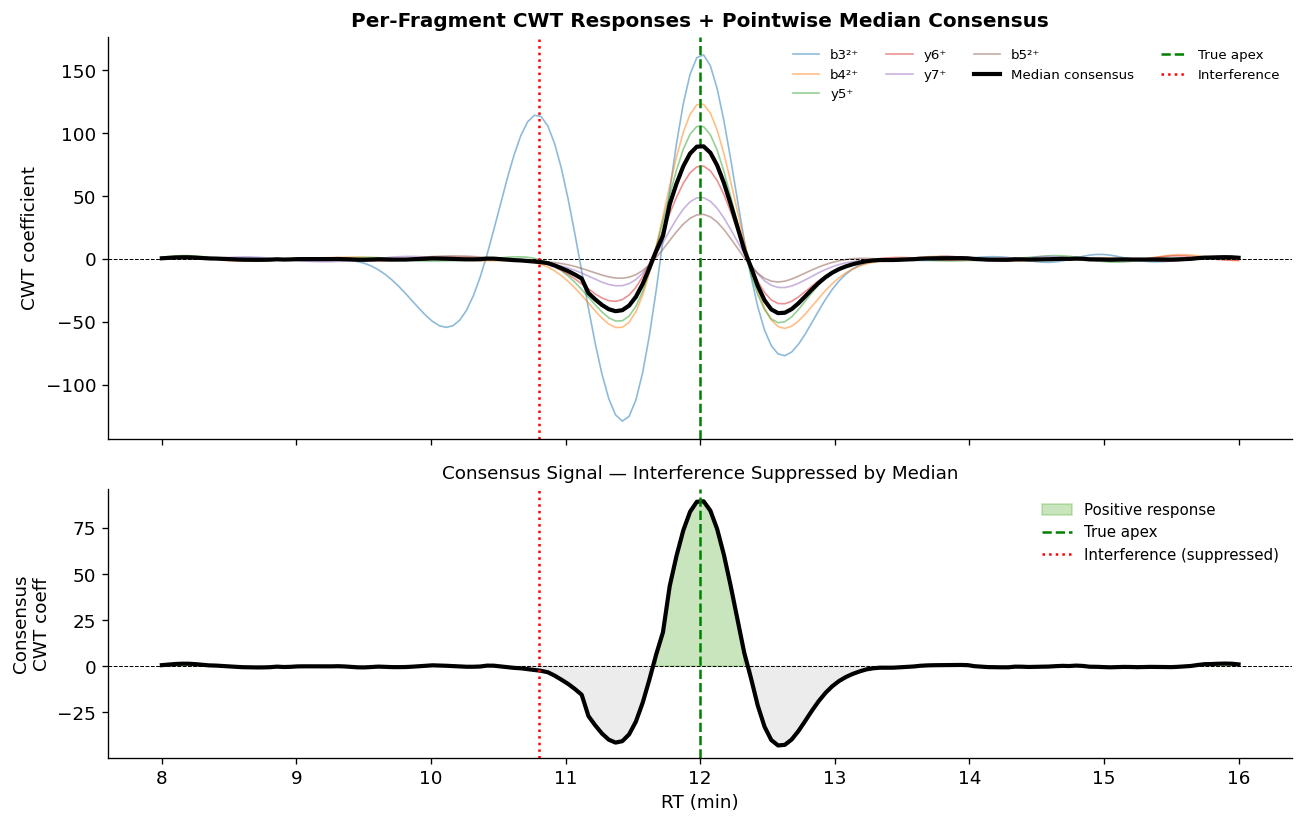

In [15]:
cwt_matrix = np.stack(cwt_coeffs, axis=0)   # shape: (n_frags, n_scans)
consensus  = np.median(cwt_matrix, axis=0)   # pointwise median

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2]})

# --- Top panel: all per-fragment CWT traces + consensus ---
ax = axes[0]
for i, (coeff, color, label) in enumerate(zip(cwt_coeffs, frag_colors, frag_labels)):
    ax.plot(rt, coeff, color=color, lw=1.0, alpha=0.5, label=label)
ax.plot(rt, consensus, color='black', lw=2.5, label='Median consensus', zorder=5)
ax.axhline(0, color='black', lw=0.6, ls='--')
ax.axvline(peptide_apex_rt, color='green', lw=1.5, ls='--', label='True apex')
ax.axvline(interference_rt, color='red', lw=1.5, ls=':', label='Interference')
ax.set_ylabel('CWT coefficient')
ax.set_title('Per-Fragment CWT Responses + Pointwise Median Consensus', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, ncol=4, frameon=False)

# --- Bottom panel: consensus only, with zero-crossing annotation ---
ax2 = axes[1]
ax2.plot(rt, consensus, color='black', lw=2.5)
ax2.fill_between(rt, consensus, 0, where=(consensus > 0), alpha=0.3, color='#4dac26', label='Positive response')
ax2.fill_between(rt, consensus, 0, where=(consensus < 0), alpha=0.15, color='gray')
ax2.axhline(0, color='black', lw=0.6, ls='--')
ax2.axvline(peptide_apex_rt, color='green', lw=1.5, ls='--', label='True apex')
ax2.axvline(interference_rt, color='red', lw=1.5, ls=':', label='Interference (suppressed)')
ax2.set_xlabel('RT (min)')
ax2.set_ylabel('Consensus\nCWT coeff')
ax2.set_title('Consensus Signal — Interference Suppressed by Median', fontsize=11)
ax2.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

## 5. Peak Detection and Boundary Extension

### Algorithm steps applied to the consensus signal:

1. **Find local maxima** above a minimum height threshold  
2. **Walk outward** from each apex to find the **zero-crossings** of the consensus signal  
3. **Estimate σ asymmetrically**: left_σ = apex − left_zero, right_σ = right_zero − apex  
4. **Extend to ±2σ** for ~95 % Gaussian area coverage  
5. **Valley guard**: during extension, monitor the raw reference signal; stop if it rises
   more than 5 % above its local minimum (prevents bleeding into neighbouring peaks)

In [16]:
def find_boundary(consensus, apex_idx, direction, min_scan, max_scan):
    """Walk from apex in ±direction. Return index of first zero crossing."""
    idx = apex_idx
    while min_scan <= idx + direction <= max_scan:
        if consensus[idx + direction] <= 0:
            return idx
        idx += direction
    return idx


def detect_peaks(consensus, rt, reference_signal=None, min_height_frac=0.05):
    """Simplified CWT consensus peak detection matching Osprey logic."""
    n = len(consensus)
    max_h = consensus.max()
    min_height = max_h * min_height_frac if max_h > 0 else 0

    # 1. Local maxima
    apices = []
    for i in range(1, n - 1):
        if consensus[i] > consensus[i-1] and consensus[i] > consensus[i+1] and consensus[i] > min_height:
            apices.append(i)

    peaks = []
    ref = reference_signal if reference_signal is not None else np.abs(consensus)

    for apex_idx in apices:
        # 2. Zero-crossings
        left_zc  = find_boundary(consensus, apex_idx, -1, 0, n-1)
        right_zc = find_boundary(consensus, apex_idx, +1, 0, n-1)

        # 3. Asymmetric sigma estimate
        left_sigma  = max(1, apex_idx - left_zc)
        right_sigma = max(1, right_zc - apex_idx)

        # 4. Extend to ±2σ
        target_left  = apex_idx - 2 * left_sigma
        target_right = apex_idx + 2 * right_sigma

        # 5. Valley guard on the reference signal
        def extend_guarded(start, stop, step):
            apex_ref = ref[apex_idx]
            threshold = 0.05 * apex_ref
            running_min = ref[start]
            idx = start
            while (step < 0 and idx + step >= stop) or (step > 0 and idx + step <= stop):
                next_idx = idx + step
                running_min = min(running_min, ref[next_idx])
                if ref[next_idx] - running_min > threshold and idx != start:
                    break
                idx = next_idx
            return max(0, min(n-1, idx))

        final_left  = extend_guarded(left_zc,  max(0, target_left),   -1)
        final_right = extend_guarded(right_zc, min(n-1, target_right), +1)

        peaks.append({
            'apex_idx': apex_idx,
            'apex_rt':  rt[apex_idx],
            'start_idx': final_left,
            'end_idx':   final_right,
            'start_rt':  rt[final_left],
            'end_rt':    rt[final_right],
            'apex_coef': consensus[apex_idx],
            'zero_left_rt':  rt[left_zc],
            'zero_right_rt': rt[right_zc],
        })

    return sorted(peaks, key=lambda p: -p['apex_coef'])


reference_signal = np.stack(xics).sum(axis=0)   # sum of all fragment intensities
peaks = detect_peaks(consensus, rt, reference_signal)

for i, p in enumerate(peaks):
    print(f"Peak {i+1}: apex RT = {p['apex_rt']:.2f} min, "
          f"boundaries = [{p['start_rt']:.2f}, {p['end_rt']:.2f}] min, "
          f"consensus coef = {p['apex_coef']:.2f}")

Peak 1: apex RT = 12.03 min, boundaries = [11.32, 12.63] min, consensus coef = 89.52


## 6. Combined Visualisation: XICs → CWT → Peak Boundaries

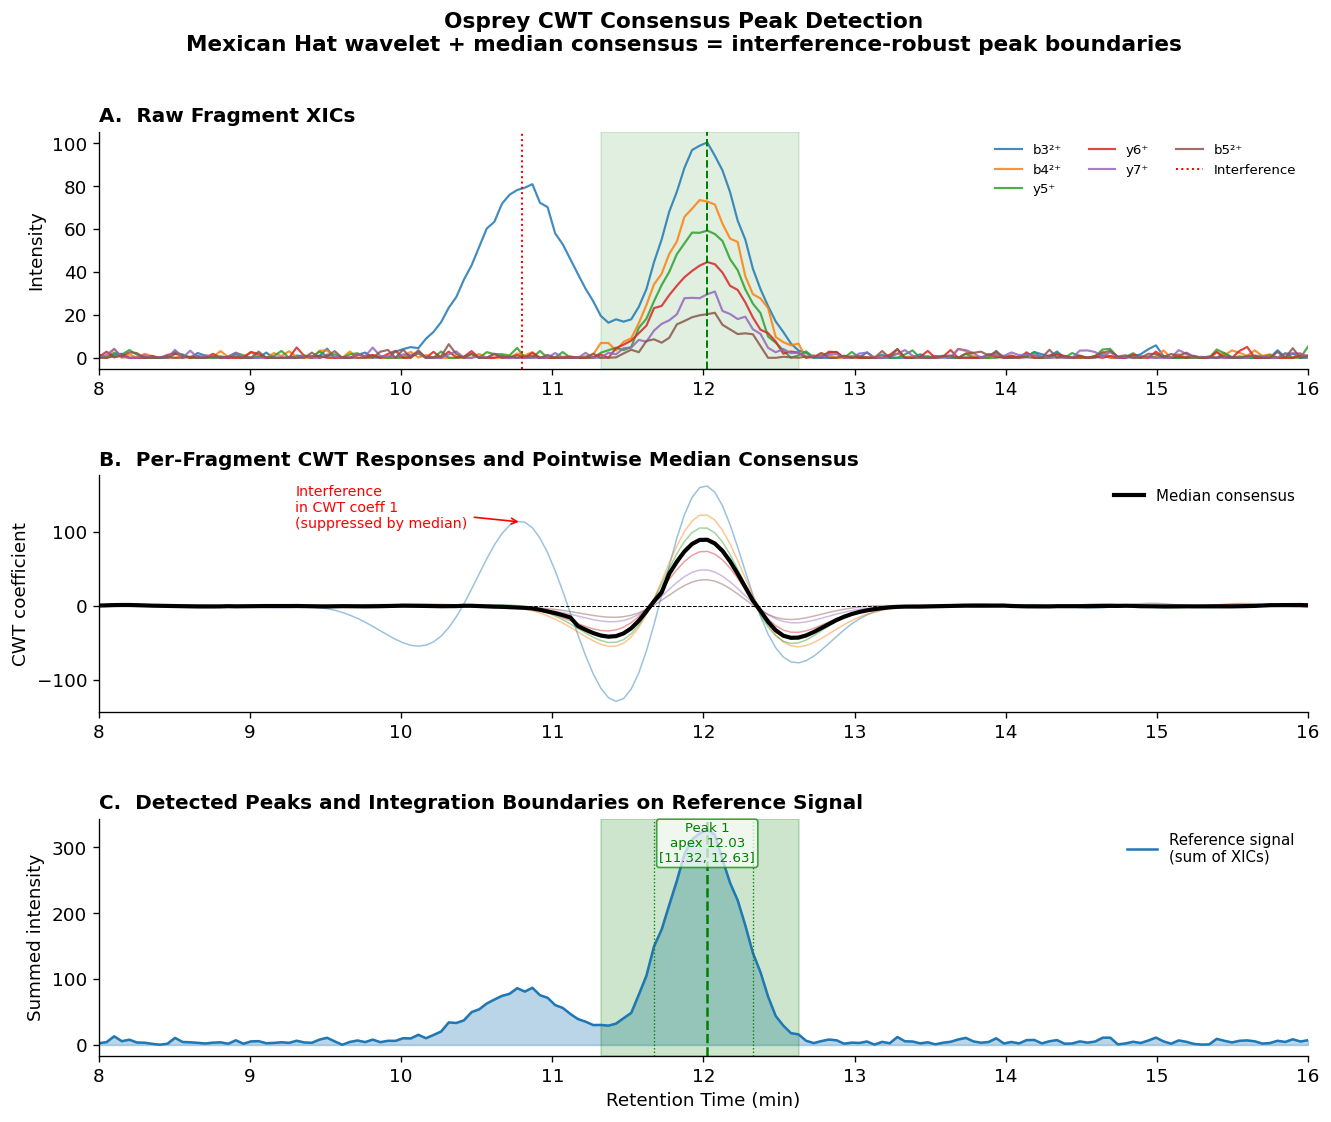

Saved: cwt_peak_detection.png


In [17]:
fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

boundary_alpha = 0.12

# ── Panel A: Raw Fragment XICs ──────────────────────────────────────────────
ax_xic = fig.add_subplot(gs[0])
for i, (xic, color, label) in enumerate(zip(xics, frag_colors, frag_labels)):
    ax_xic.plot(rt, xic, color=color, lw=1.3, label=label, alpha=0.85)

for p in peaks:
    ax_xic.axvspan(p['start_rt'], p['end_rt'], alpha=boundary_alpha, color='green')
    ax_xic.axvline(p['apex_rt'], color='green', lw=1.2, ls='--')

ax_xic.axvline(interference_rt, color='red', lw=1.2, ls=':', label='Interference')
ax_xic.set_ylabel('Intensity')
ax_xic.set_title('A.  Raw Fragment XICs', fontsize=12, fontweight='bold', loc='left')
ax_xic.legend(fontsize=8, ncol=3, frameon=False)

# ── Panel B: Per-fragment CWT + consensus ──────────────────────────────────
ax_cwt = fig.add_subplot(gs[1], sharex=ax_xic)
for i, (coeff, color) in enumerate(zip(cwt_coeffs, frag_colors)):
    ax_cwt.plot(rt, coeff, color=color, lw=0.9, alpha=0.45)
ax_cwt.plot(rt, consensus, color='black', lw=2.5, label='Median consensus', zorder=5)
ax_cwt.axhline(0, color='black', lw=0.6, ls='--')
ax_cwt.set_ylabel('CWT coefficient')
ax_cwt.set_title('B.  Per-Fragment CWT Responses and Pointwise Median Consensus',
                  fontsize=12, fontweight='bold', loc='left')
ax_cwt.legend(fontsize=9, frameon=False)

# Annotate interference suppression
ax_cwt.annotate('Interference\nin CWT coeff 1\n(suppressed by median)',
                xy=(interference_rt, cwt_coeffs[0][np.argmin(np.abs(rt - interference_rt))]),
                xytext=(interference_rt - 1.5, cwt_coeffs[0].max() * 0.65),
                fontsize=8.5, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

# ── Panel C: Detected peaks on reference signal ────────────────────────────
ax_peaks = fig.add_subplot(gs[2], sharex=ax_xic)
ax_peaks.fill_between(rt, reference_signal, alpha=0.3, color='#1f77b4')
ax_peaks.plot(rt, reference_signal, color='#1f77b4', lw=1.5, label='Reference signal\n(sum of XICs)')

peak_colors_detect = ['green', 'darkorange']
for i, p in enumerate(peaks):
    c = peak_colors_detect[i % len(peak_colors_detect)]
    ax_peaks.axvspan(p['start_rt'], p['end_rt'], alpha=0.2, color=c)
    ax_peaks.axvline(p['apex_rt'], color=c, lw=1.5, ls='--')
    ax_peaks.axvline(p['zero_left_rt'],  color=c, lw=0.8, ls=':')
    ax_peaks.axvline(p['zero_right_rt'], color=c, lw=0.8, ls=':')

    # label the boundaries
    y_label = reference_signal.max() * (0.85 - 0.15 * i)
    ax_peaks.annotate(f"Peak {i+1}\napex {p['apex_rt']:.2f}\n"
                      f"[{p['start_rt']:.2f}, {p['end_rt']:.2f}]",
                      xy=(p['apex_rt'], y_label), ha='center', fontsize=8, color=c,
                      bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c, alpha=0.7))

ax_peaks.set_xlabel('Retention Time (min)')
ax_peaks.set_ylabel('Summed intensity')
ax_peaks.set_title('C.  Detected Peaks and Integration Boundaries on Reference Signal',
                   fontsize=12, fontweight='bold', loc='left')
ax_peaks.legend(fontsize=9, frameon=False)

for ax in [ax_xic, ax_cwt, ax_peaks]:
    ax.set_xlim(rt[0], rt[-1])

fig.suptitle('Osprey CWT Consensus Peak Detection\n'
             'Mexican Hat wavelet + median consensus = interference-robust peak boundaries',
             fontsize=13, fontweight='bold')
plt.savefig('cwt_peak_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cwt_peak_detection.png')

## 7. Effect of Scale Mismatch

Using the wrong wavelet scale either misses narrow peaks (σ too large) or creates
spurious detections from noise (σ too small). Osprey estimates σ from the median
FWHM of the data itself, which makes it adaptive.

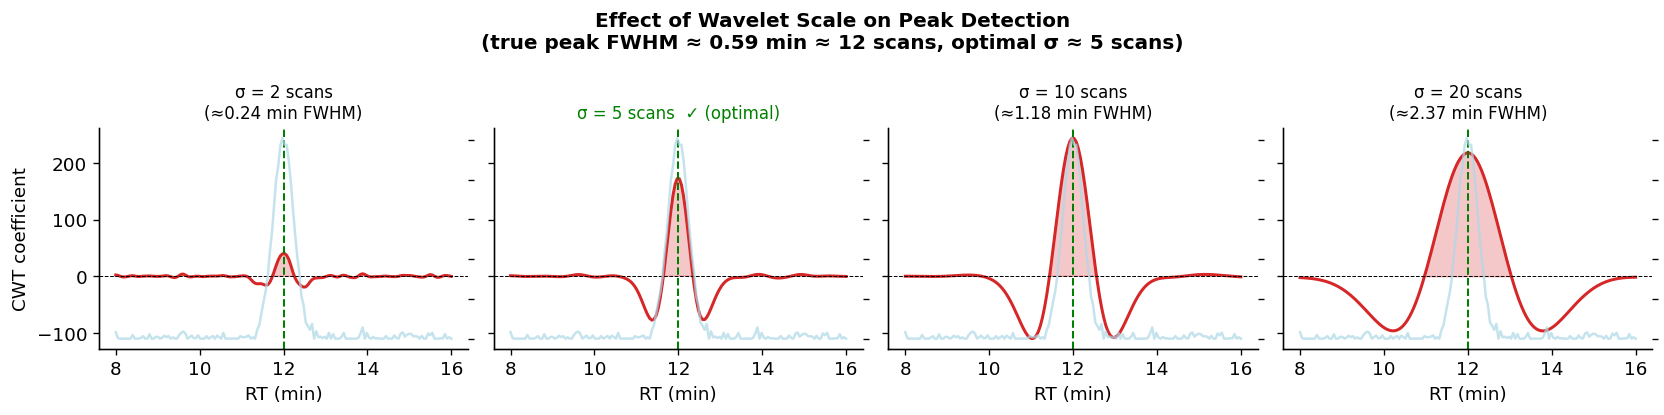

In [18]:
test_sigmas = [2, 5, 10, 20]
ncols = len(test_sigmas)
fig, axes = plt.subplots(1, ncols, figsize=(14, 3.5), sharex=True, sharey=True)

# Use fragment 1's XIC (clean, true peak)
xic_clean = gaussian_peak(rt, peptide_apex_rt, 100, peptide_peak_sigma) + rng.normal(0, 2, len(rt))
xic_clean = np.clip(xic_clean, 0, None)

for ax, sigma_test in zip(axes, test_sigmas):
    cwt_test = cwt_convolve(xic_clean, sigma_test)
    ax2 = ax.twinx()
    ax2.plot(rt, xic_clean, color='lightblue', lw=1.5, alpha=0.7)
    ax2.set_yticklabels([])
    ax.plot(rt, cwt_test, color='#d62728', lw=1.8)
    ax.fill_between(rt, cwt_test, 0, where=(cwt_test > 0), alpha=0.25, color='#d62728')
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.axvline(peptide_apex_rt, color='green', lw=1.2, ls='--')
    fwhm_approx = 2.355 * sigma_test * scan_width_min
    ax.set_title(f'σ = {sigma_test} scans\n(≈{fwhm_approx:.2f} min FWHM)', fontsize=10)
    ax.set_xlabel('RT (min)')

axes[0].set_ylabel('CWT coefficient')
# Mark the correct scale
optimal_idx = test_sigmas.index(5)   # σ=5 is closest to true σ≈5
axes[optimal_idx].set_title(f'σ = {test_sigmas[optimal_idx]} scans  ✓ (optimal)',
                            fontsize=10, color='green')

fig.suptitle('Effect of Wavelet Scale on Peak Detection\n'
             '(true peak FWHM ≈ 0.59 min ≈ 12 scans, optimal σ ≈ 5 scans)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()